#### Setup Step 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

#### Setup Step 3

In [2]:
df=pd.read_csv('Bank-Telemarketing.csv')

#### Setup Step 4

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

#### EDA

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
for col in df.columns:
    print(f"--- {col} ---")
    print(df[col].value_counts(), "\n")

--- age ---
age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
89       2
91       2
94       1
87       1
95       1
Name: count, Length: 78, dtype: int64 

--- job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64 

--- marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64 

--- education ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64 

--- default ---
default
no         32588
unknown     8597
yes            3
Name: count, dty

In [7]:
#Check for Missing Values
features_na = [feature for feature in df.columns if df[feature].isnull().sum() > 0]

if len(features_na) == 0:
    print("No missing values found")
else:
    for feature in features_na:
        print(feature, np.round(df[feature].isnull().mean() * 100, 4), "% missing values")

No missing values found


In [8]:
#drop leakage column
df = df.drop('duration', axis=1)

In [9]:
#separate feature types into categorical and numerical features
categorical_features = df.select_dtypes(include='object').columns.tolist()
numerical_features = df.select_dtypes(exclude='object').columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
Numerical: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [10]:
#Check target label split over categorical features and find the count
for categorical_feature in categorical_features:
    print(df.groupby(['y',categorical_feature]).size())

y    job          
no   admin.           9070
     blue-collar      8616
     entrepreneur     1332
     housemaid         954
     management       2596
     retired          1286
     self-employed    1272
     services         3646
     student           600
     technician       6013
     unemployed        870
     unknown           293
yes  admin.           1352
     blue-collar       638
     entrepreneur      124
     housemaid         106
     management        328
     retired           434
     self-employed     149
     services          323
     student           275
     technician        730
     unemployed        144
     unknown            37
dtype: int64
y    marital 
no   divorced     4136
     married     22396
     single       9948
     unknown        68
yes  divorced      476
     married      2532
     single       1620
     unknown        12
dtype: int64
y    education          
no   basic.4y                3748
     basic.6y                2104
     basic.9y   

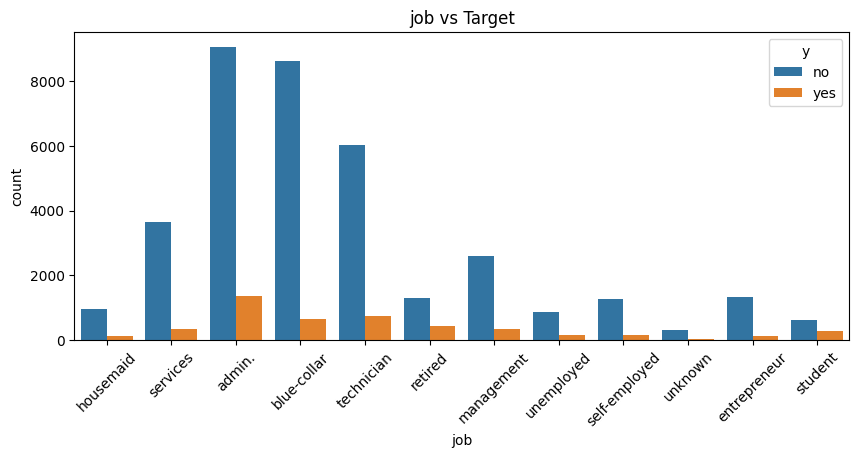

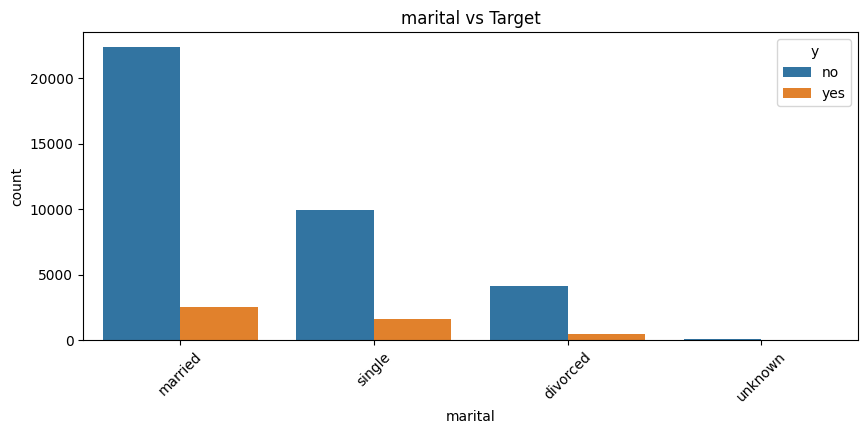

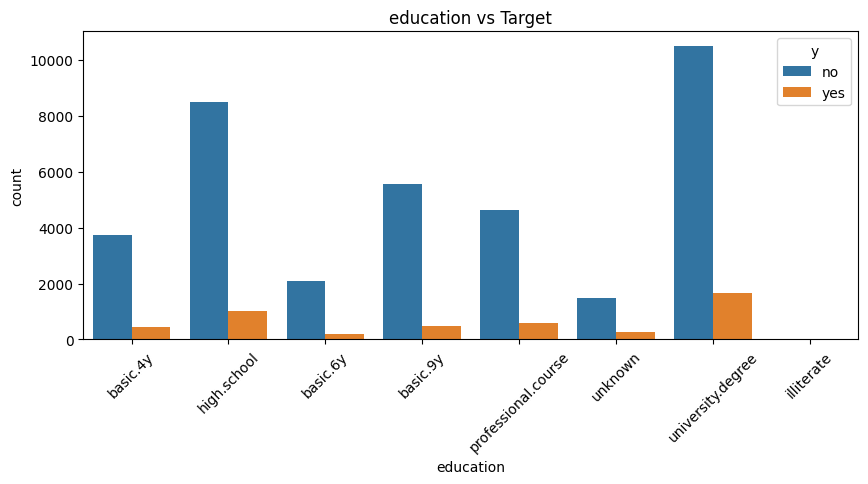

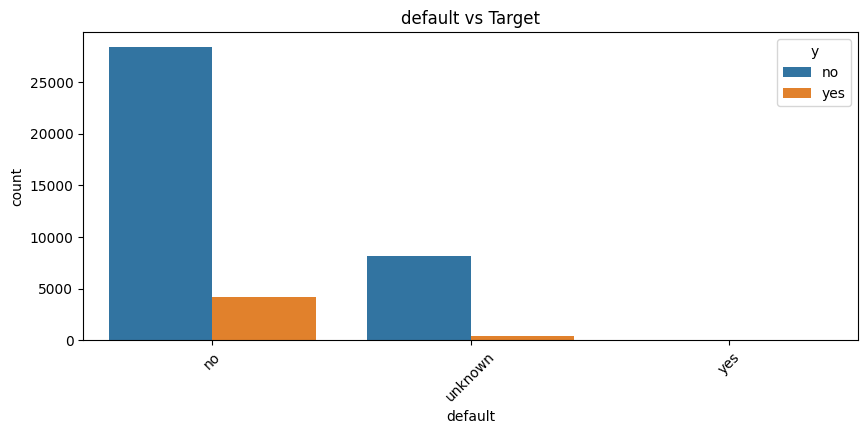

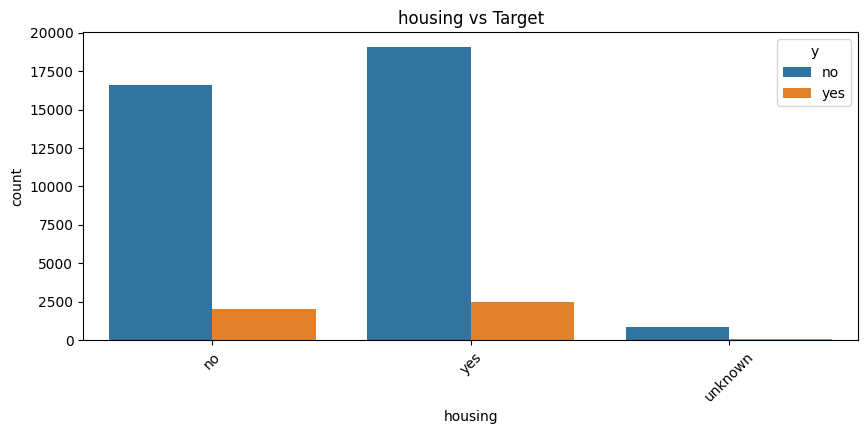

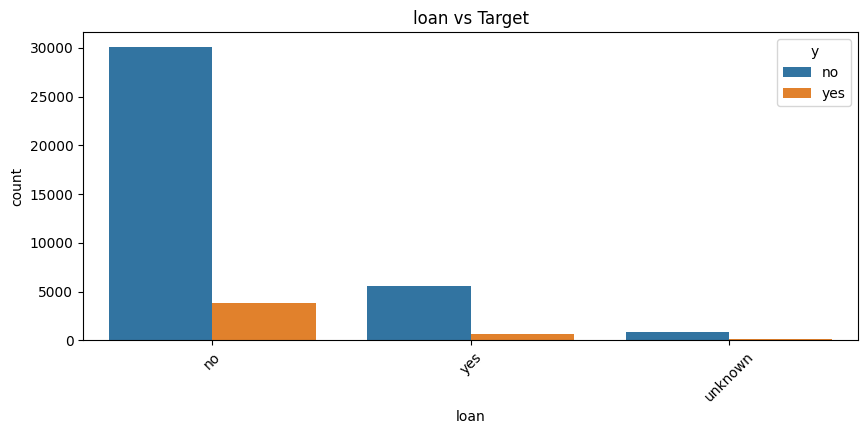

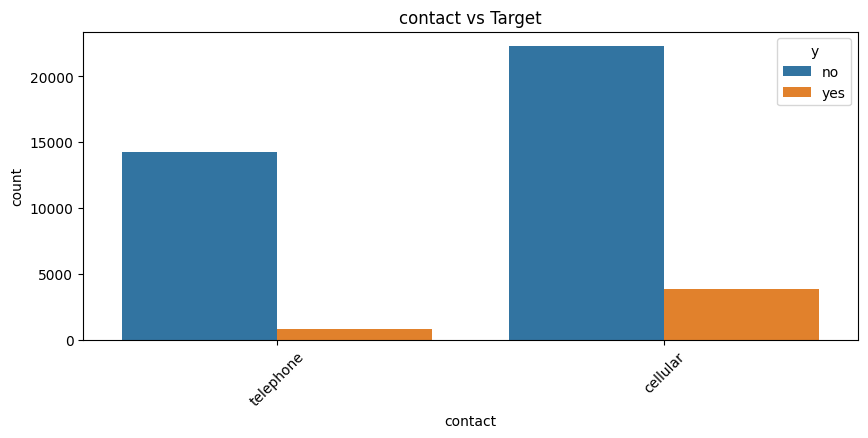

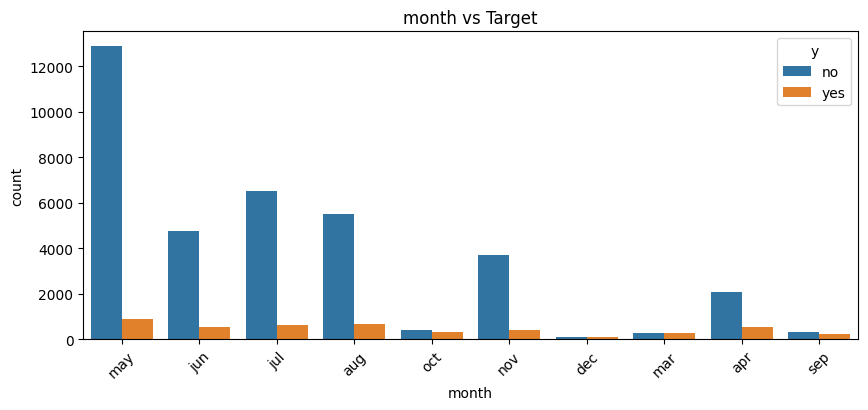

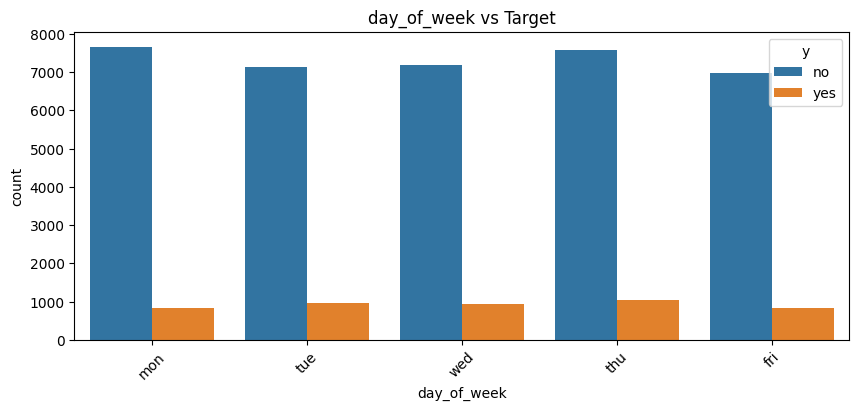

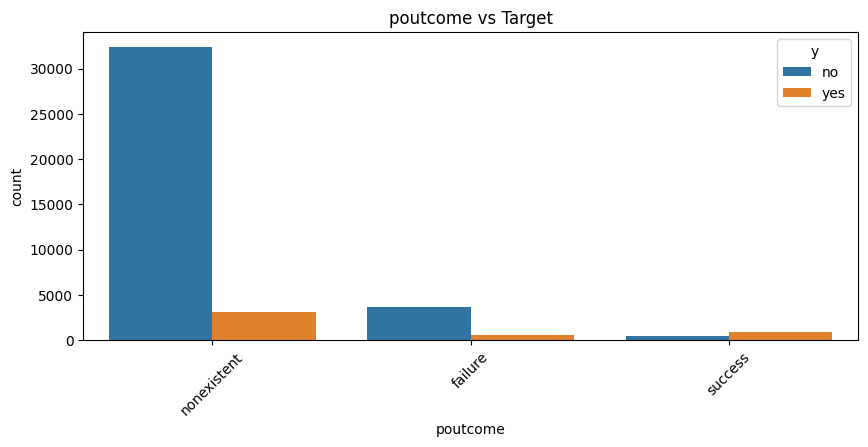

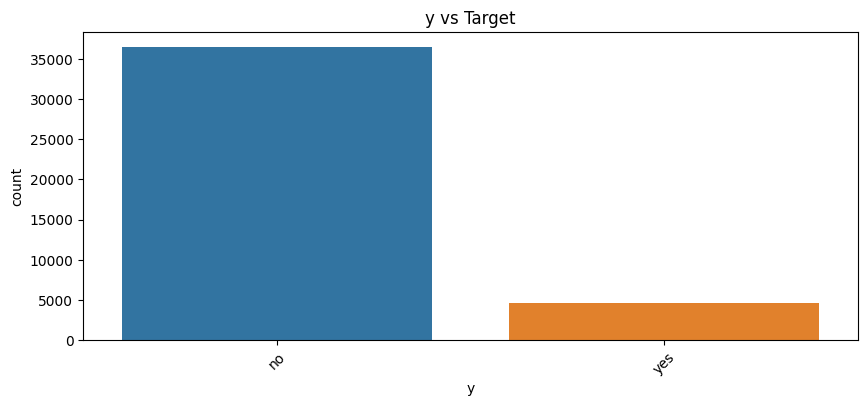

In [11]:
#Visualize
for feature in categorical_features:
    plt.figure(figsize=(10,4))
    sns.countplot(x=feature, hue='y', data=df)
    plt.xticks(rotation=45)
    plt.title(f"{feature} vs Target")
    plt.show()

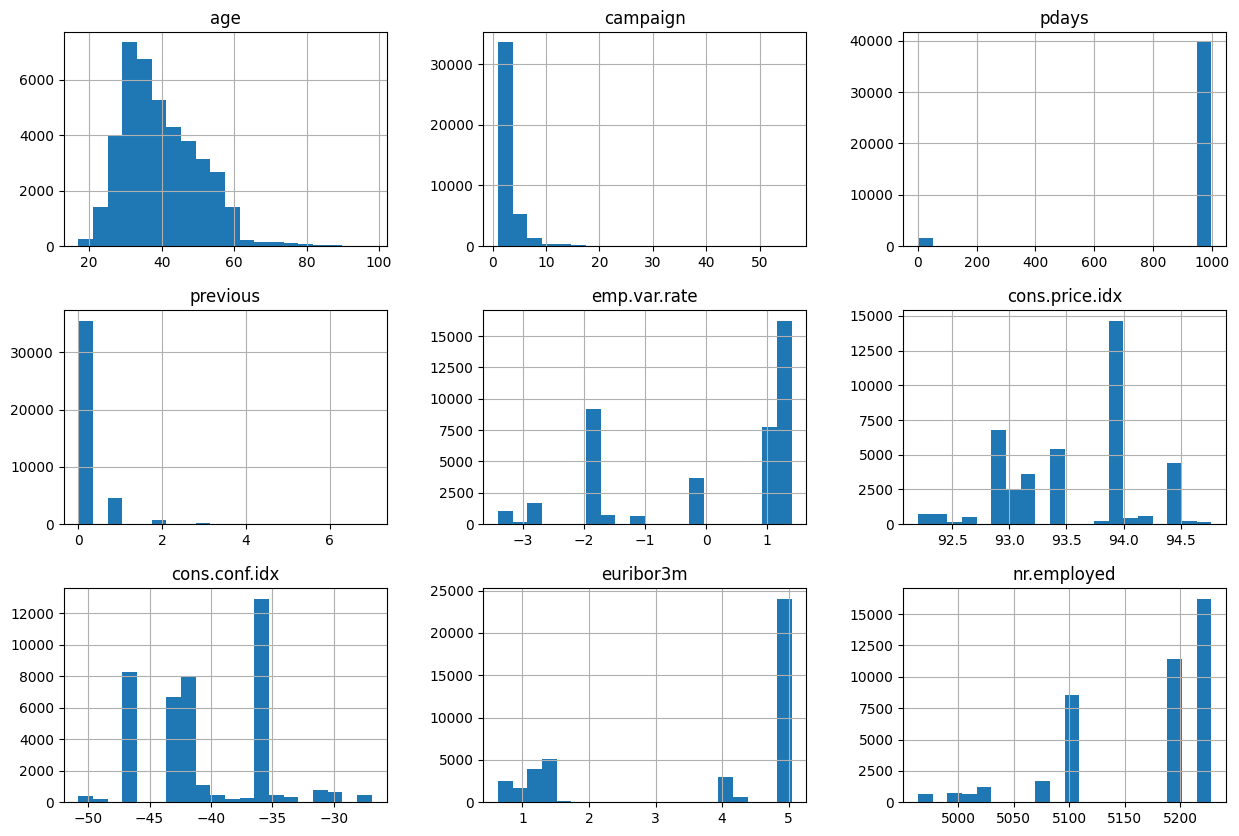

In [12]:
#Visualize Distributions for Numerical Features
df[numerical_features].hist(figsize=(15,10), bins=20)
plt.show()

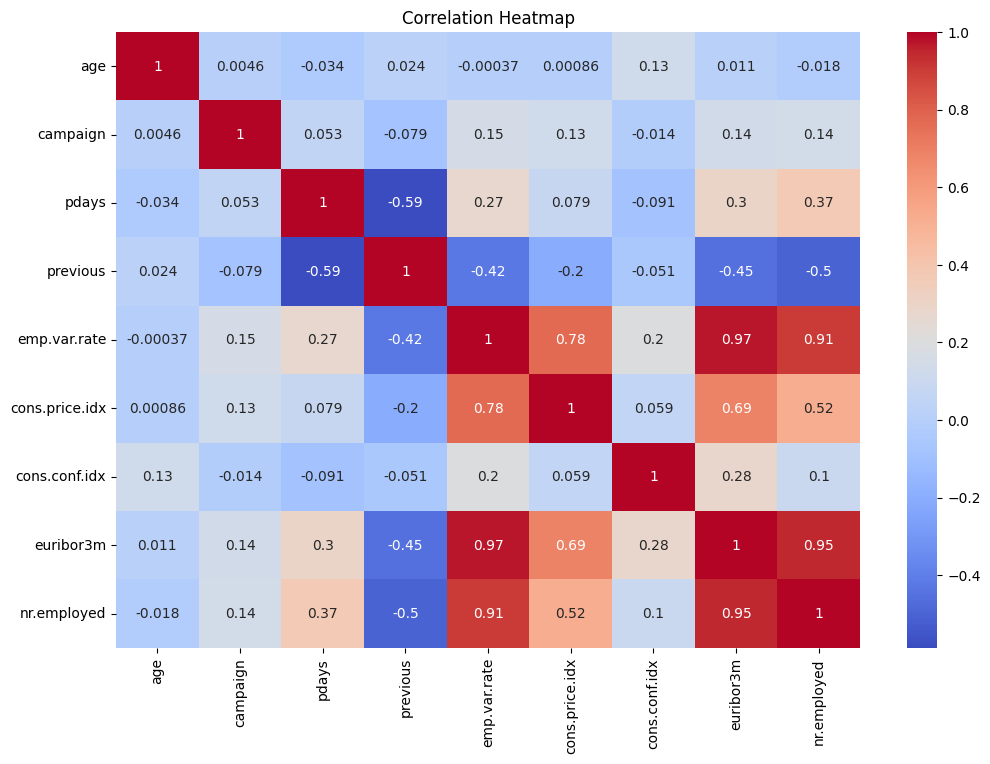

In [13]:
#Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [14]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [15]:
#Pearson correlation for  with target variable 'y'
corr_with_target = df.corr(numeric_only=True)['y'].sort_values(ascending=False)

print(corr_with_target)


y                 1.000000
previous          0.230181
cons.conf.idx     0.054878
age               0.030399
campaign         -0.066357
cons.price.idx   -0.136211
emp.var.rate     -0.298334
euribor3m        -0.307771
pdays            -0.324914
nr.employed      -0.354678
Name: y, dtype: float64


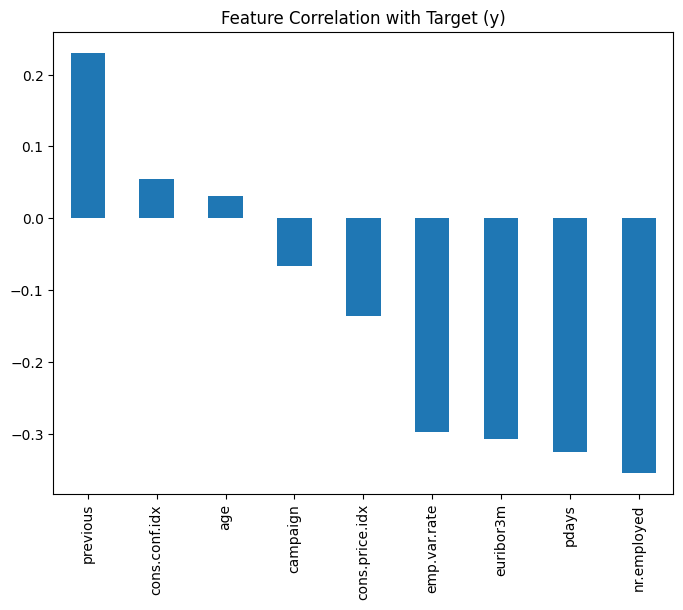

In [16]:
#Visualize
plt.figure(figsize=(8,6))
corr_with_target.drop('y').plot(kind='bar')
plt.title("Feature Correlation with Target (y)")
plt.show()


In [17]:
# Target Rate for Categorical Feature Impact on 'y'
for col in categorical_features:
    print("\n", col)
    print(df.groupby(col)['y'].mean().sort_values(ascending=False))


 job
job
student          0.314286
retired          0.252326
unemployed       0.142012
admin.           0.129726
management       0.112175
unknown          0.112121
technician       0.108260
self-employed    0.104856
housemaid        0.100000
entrepreneur     0.085165
services         0.081381
blue-collar      0.068943
Name: y, dtype: float64

 marital
marital
unknown     0.150000
single      0.140041
divorced    0.103209
married     0.101573
Name: y, dtype: float64

 education
education
illiterate             0.222222
unknown                0.145003
university.degree      0.137245
professional.course    0.113485
high.school            0.108355
basic.4y               0.102490
basic.6y               0.082024
basic.9y               0.078246
Name: y, dtype: float64

 default
default
no         0.12879
unknown    0.05153
yes        0.00000
Name: y, dtype: float64

 housing
housing
yes        0.116194
no         0.108796
unknown    0.108081
Name: y, dtype: float64

 loan
loan
no         0.

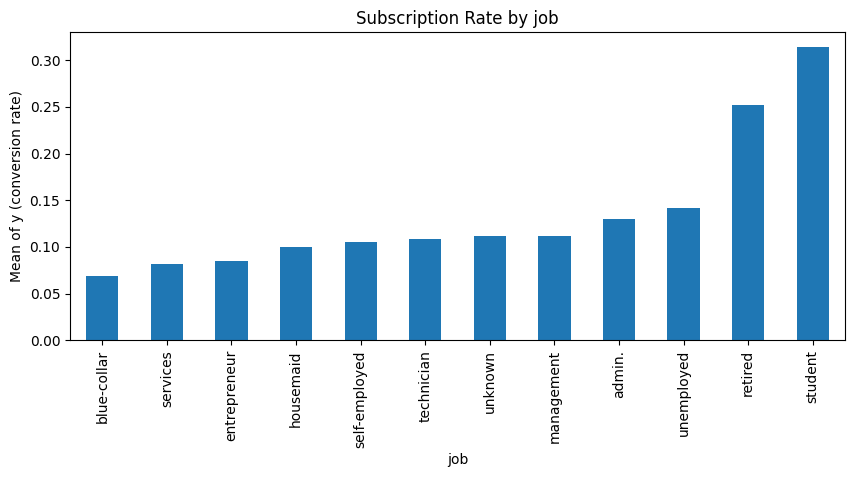

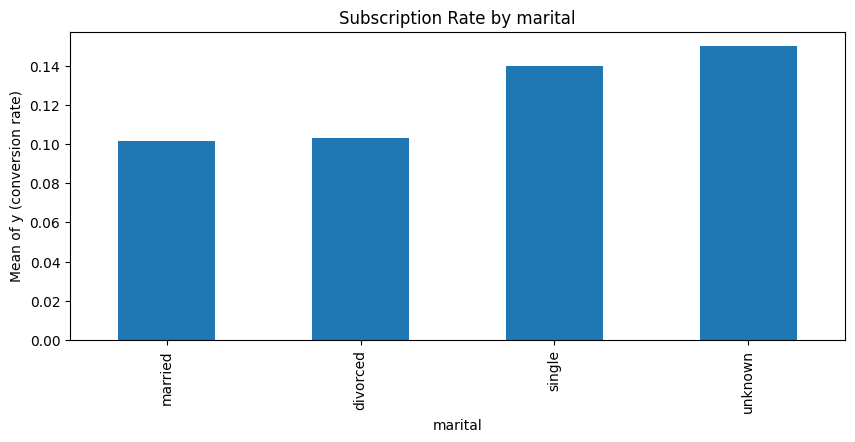

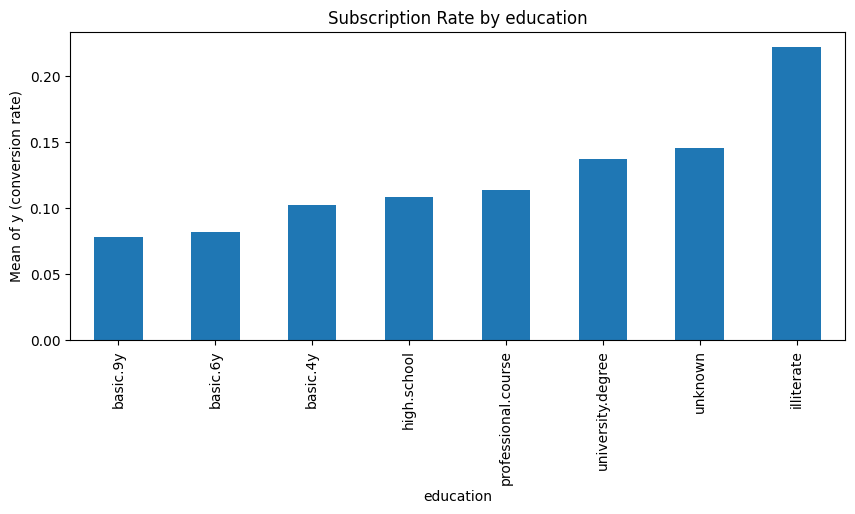

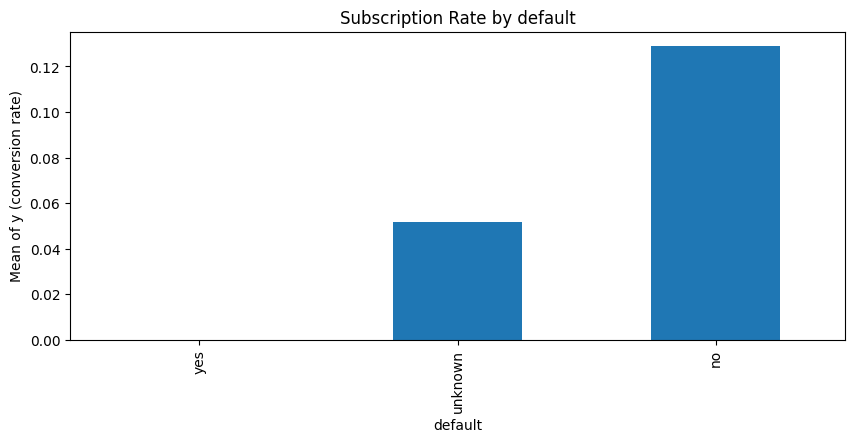

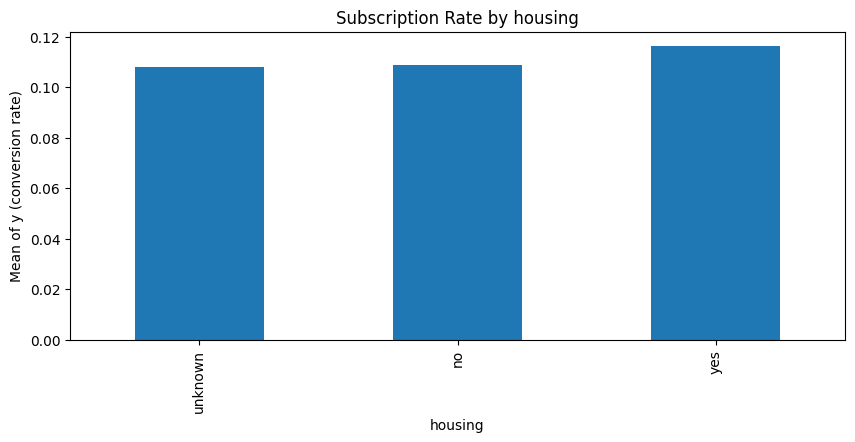

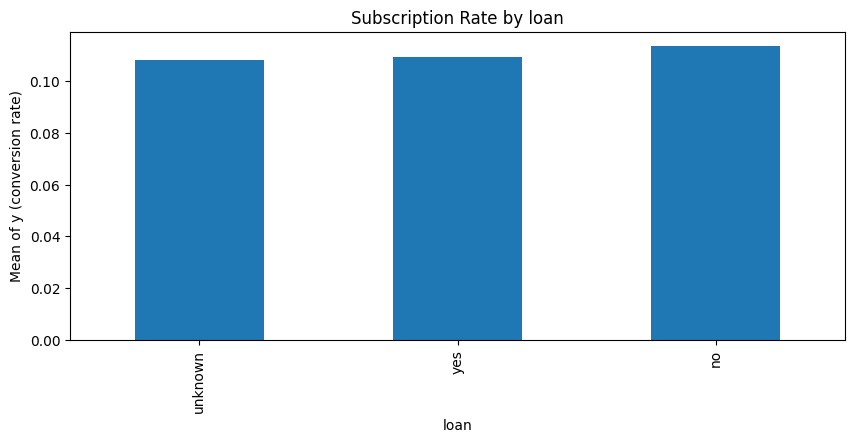

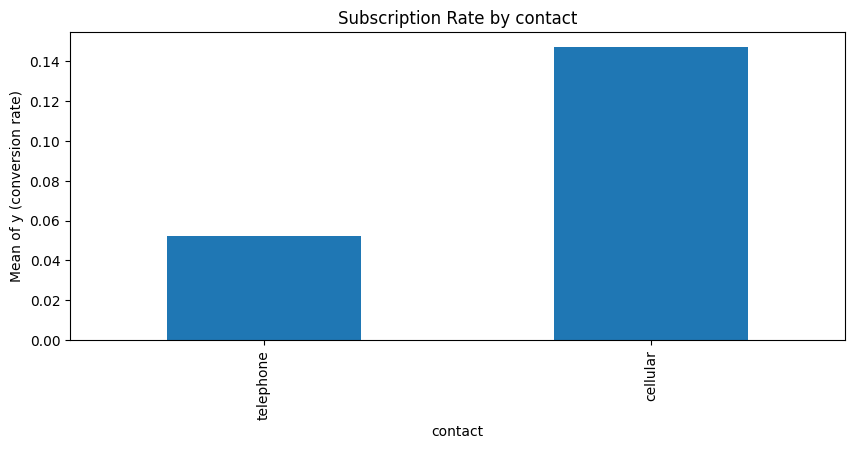

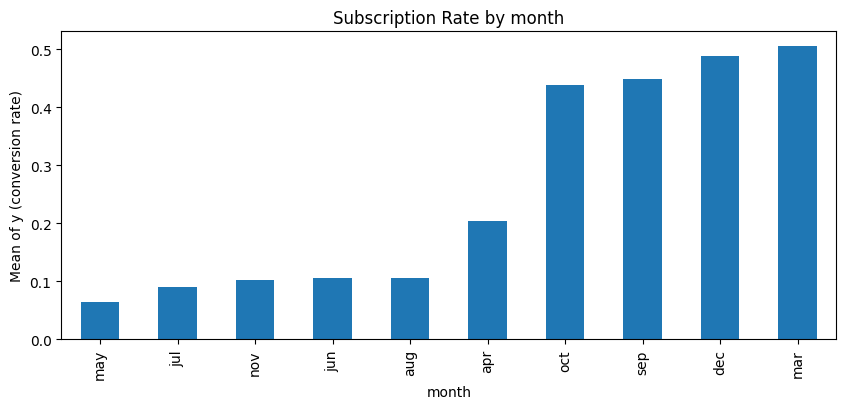

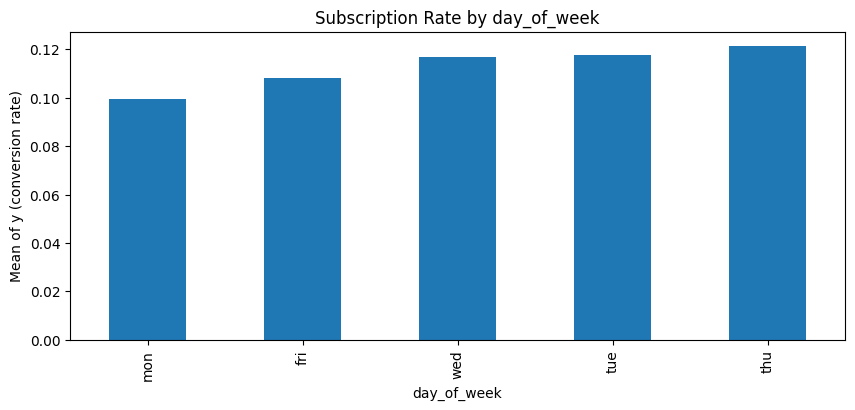

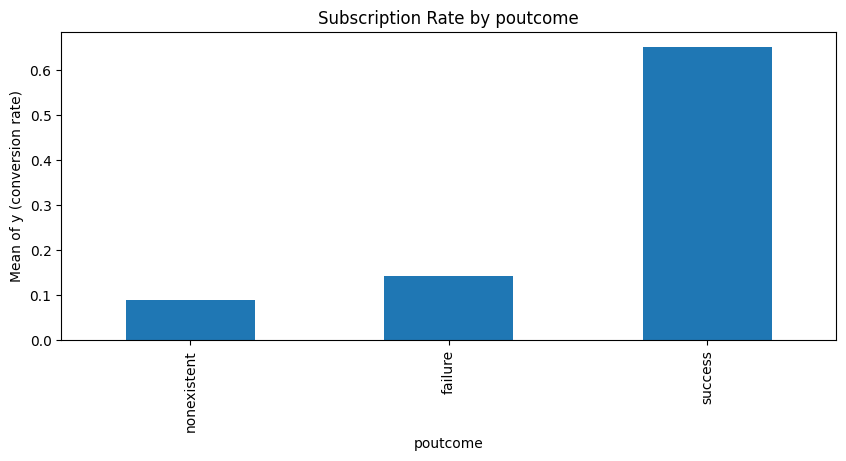

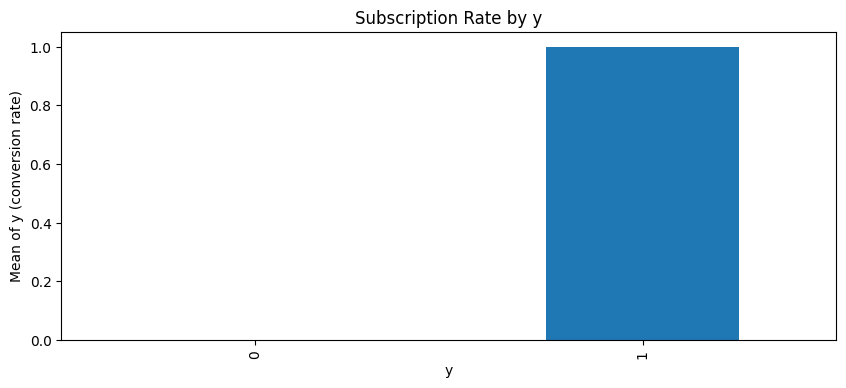

In [18]:
#Visualize
for col in categorical_features:
    plt.figure(figsize=(10,4))
    df.groupby(col)['y'].mean().sort_values().plot(kind='bar')
    plt.title(f"Subscription Rate by {col}")
    plt.ylabel("Mean of y (conversion rate)")
    plt.show()

In [19]:
# One-hot encoding of categorical features
df_encoded = pd.get_dummies(df.drop('y', axis=1), drop_first=True)


#Compute mutual information
mi = mutual_info_classif(df_encoded, df['y'])
mi_series = pd.Series(mi, index=df_encoded.columns)
mi_series.sort_values(ascending=False).head(15)

euribor3m               0.075121
cons.price.idx          0.070755
cons.conf.idx           0.068409
nr.employed             0.064556
emp.var.rate            0.056713
pdays                   0.041354
poutcome_success        0.029990
poutcome_nonexistent    0.021268
previous                0.019619
contact_telephone       0.015562
age                     0.013668
month_may               0.009456
marital_married         0.007173
month_oct               0.007035
month_mar               0.006458
dtype: float64

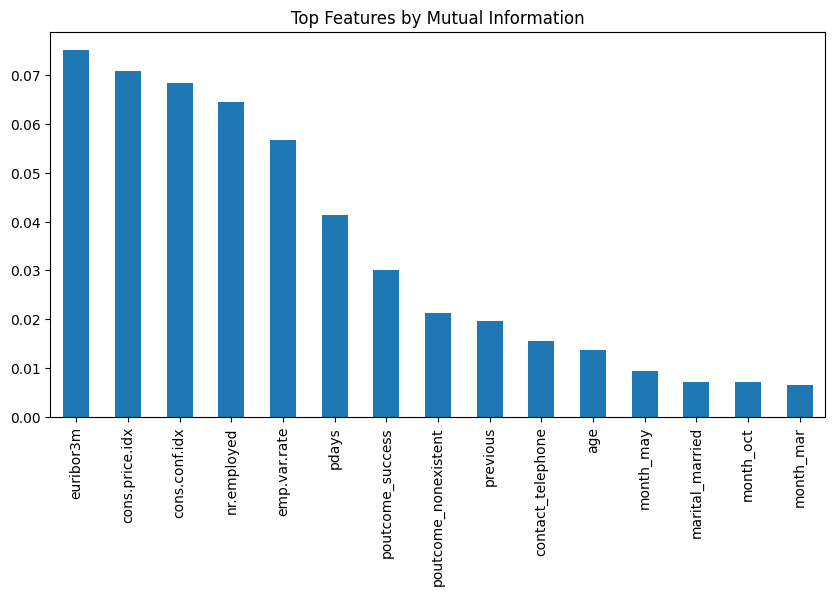

In [20]:
mi_series.sort_values(ascending=False).head(15).plot(kind='bar', figsize=(10,5))
plt.title("Top Features by Mutual Information")
plt.show()

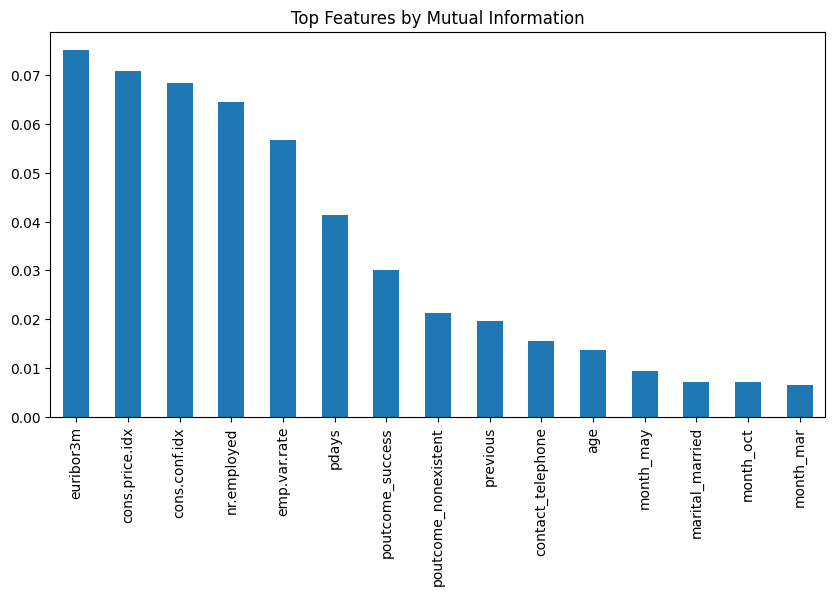

In [21]:
mi_series.sort_values(ascending=False).head(15).plot(kind='bar', figsize=(10,5))
plt.title("Top Features by Mutual Information")
plt.show()

In [22]:
#Check target distribution
df['y'].value_counts(normalize=True)

y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

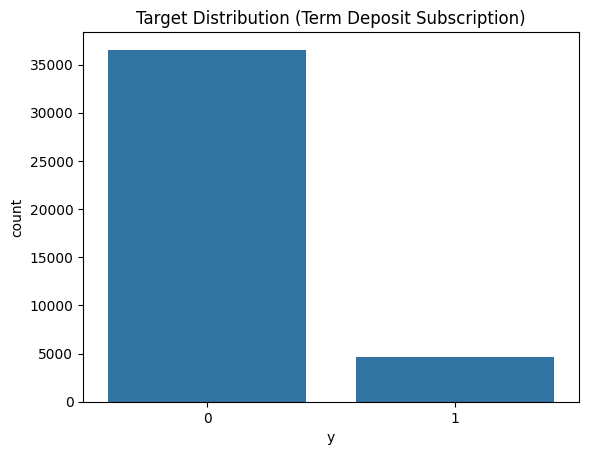

In [23]:
sns.countplot(x='y', data=df)
plt.title("Target Distribution (Term Deposit Subscription)")
plt.show()

#### Preprocessing and Feature Engineering

##### new features 'contact_intensity' & 'was_previously_contacted'

In [24]:
df=df.copy()

In [25]:
df['contact_intensity'] = df['campaign'] / (df['previous'] + 1)

In [26]:
df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)

In [27]:
df['pdays'] = df['pdays'].replace(999, -1)

#### Model Training

In [28]:
X = df_encoded
y = df['y']


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print(df_encoded.shape)
print('y' in df_encoded.columns)

(41188, 52)
False


In [31]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(32950, 52)
(8238, 52)
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


In [32]:
#Handle class imbalance with SMOTE
%pip install -U imbalanced-learn
from imblearn.over_sampling import SMOTE

Note: you may need to restart the kernel to use updated packages.


In [33]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [34]:
#Verify
print(y_train.value_counts())

print("\nAfter SMOTE:\n")

print(y_train_resampled.value_counts())

y
0    29238
1     3712
Name: count, dtype: int64

After SMOTE:

y
0    29238
1    29238
Name: count, dtype: int64


In [35]:
print(df_encoded.shape)
print(X_train.shape)
print(X_train_resampled.shape)

(41188, 52)
(32950, 52)
(58476, 52)


In [36]:
#Experiment Tracking with MLflow
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Bank_Telemarketing")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1780608874605, experiment_id='1', last_update_time=1780608874605, lifecycle_stage='active', name='Bank_Telemarketing', tags={}, workspace='default'>

In [37]:
#Logistic Regression Baseline Model

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

with mlflow.start_run(run_name="LogisticRegression"):

    lr = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    lr.fit(X_train_resampled, y_train_resampled)

    y_pred = lr.predict(X_test)
    y_proba = lr.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    mlflow.log_param("max_iter", 1000)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    mlflow.sklearn.log_model(lr, name="model")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/06/05 12:02:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LogisticRegression at: http://127.0.0.1:5000/#/experiments/1/runs/be2e4473eb704226853b5913d1ccffc9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Accuracy: 0.8432872056324351
Precision: 0.3506172839506173
Recall: 0.45905172413793105
F1: 0.39757349510032663
ROC-AUC: 0.7341138585546487


In [39]:
#Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="RandomForest"):

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_resampled, y_train_resampled)

    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    mlflow.log_param("n_estimators", 200)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    mlflow.sklearn.log_model(rf, name="model")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)

2026/06/05 12:02:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest at: http://127.0.0.1:5000/#/experiments/1/runs/d41cabaf12bc47a5bb329a66fcb14ed4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Accuracy: 0.8865015780529255
Precision: 0.49547218628719275
Recall: 0.41271551724137934
F1: 0.4503233392122281
ROC-AUC: 0.7771869398320675


In [41]:
# XGBoost

In [42]:
from xgboost import XGBClassifier

with mlflow.start_run(run_name="XGBoost"):

    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric='logloss'
    )

    xgb.fit(X_train_resampled, y_train_resampled)

    y_pred = xgb.predict(X_test)
    y_proba = xgb.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 6)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    mlflow.sklearn.log_model(xgb, name="model")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)

2026/06/05 12:03:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/1/runs/01179bd3ef254a38ac623a8c0bf89170
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Accuracy: 0.8900218499635834
Precision: 0.513126491646778
Recall: 0.46336206896551724
F1: 0.4869762174405436
ROC-AUC: 0.7898340576206425


In [43]:
# LightGBM

In [44]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

with mlflow.start_run(run_name="LightGBM"):

    lgb = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42
    )

    lgb.fit(X_train_resampled, y_train_resampled)

    y_pred = lgb.predict(X_test)
    y_proba = lgb.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", -1)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    mlflow.sklearn.log_model(lgb, name="model")

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc)
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

[LightGBM] [Info] Number of positive: 29238, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005758 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1059
[LightGBM] [Info] Number of data points in the train set: 58476, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


2026/06/05 12:03:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LightGBM at: http://127.0.0.1:5000/#/experiments/1/runs/9e1ef940cbef488dadf78ea5019d19b5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Accuracy: 0.8922068463219228
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7310
           1       0.52      0.47      0.49       928

    accuracy                           0.89      8238
   macro avg       0.73      0.71      0.72      8238
weighted avg       0.89      0.89      0.89      8238

ROC-AUC: 0.7944370901929336

Confusion Matrix:

[[6916  394]
 [ 494  434]]


In [45]:
#Save Final Model 
import joblib

joblib.dump(lgb, "lightgbm_model.pkl")

['lightgbm_model.pkl']

In [46]:
joblib.dump(df_encoded.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [47]:
thresholds = [0.5, 0.4, 0.3, 0.25]

for t in thresholds:

    y_pred_threshold = (y_proba >= t).astype(int)

    print("Threshold:", t)
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall:", recall_score(y_test, y_pred_threshold))
    print("F1:", f1_score(y_test, y_pred_threshold))
    print("-" * 30)

Threshold: 0.5
Precision: 0.5241545893719807
Recall: 0.4676724137931034
F1: 0.49430523917995445
------------------------------
Threshold: 0.4
Precision: 0.47141518275538896
Recall: 0.5420258620689655
F1: 0.5042606516290726
------------------------------
Threshold: 0.3
Precision: 0.41429613420860684
Recall: 0.6120689655172413
F1: 0.4941278816876903
------------------------------
Threshold: 0.25
Precision: 0.37054918527459263
Recall: 0.6616379310344828
F1: 0.47504835589941974
------------------------------


In [48]:
BEST_THRESHOLD = 0.4